# Checkpoint 05 - Redes Neurais e Deep Learning
## Homer vs Bart com CNN

**Aluno:** Tiago Cesaro - RM 569374

## Etapa 1 - Definição do problema

A ideia desse trabalho é montar uma CNN que olhe uma imagem e diga se é o Homer
ou o Bart. É um problema de classificação com duas classes.

Pra isso eu vou treinar a rede com imagens dos dois, medir o acerto em imagens
que ela não viu no treino e, no fim, testar Transfer Learning (VGG16) pra tentar
melhorar, já que tenho poucas imagens.

O dataset tem 196 imagens de treino (118 Bart / 78 Homer) e 73 de teste
(42 Bart / 31 Homer).

## Etapa 2 - Preparação dos dados

Antes de montar a rede, preciso trazer as imagens pro Colab. Começo importando
as bibliotecas que vou usar no trabalho todo.

In [1]:
# Bibliotecas que vamos usar no trabalho todo

import numpy as np              # trabalhar com números/arrays (a imagem vira matriz de números)
import tensorflow as tf         # construir e treinar a rede neural (Keras vem junto)
import zipfile, tempfile, os    # abrir o .zip e lidar com as pastas
import matplotlib.pyplot as plt # mostrar as imagens e os gráficos

print('TensorFlow versão:', tf.__version__)

TensorFlow versão: 2.21.0


### Enviando o dataset pro Colab

A célula abaixo abre uma janela pra eu escolher o arquivo
dataset_personagens.zip do meu computador. Tenho que esperar o upload terminar
antes de rodar a próxima célula.

In [2]:
from google.colab import files
enviados = files.upload()

Saving dataset_personagens.zip to dataset_personagens.zip


### Extraindo as imagens

Aqui eu descompacto o zip. As imagens já vêm separadas em treino e teste, cada
uma com as pastas bart e homer:

In [3]:
# Cria uma pasta temporária e extrai o zip dentro dela
temp_dir = tempfile.TemporaryDirectory()

with zipfile.ZipFile('dataset_personagens.zip', 'r') as zip:
    zip.extractall(temp_dir.name)

# Guarda os caminhos das pastas de treino e teste em variáveis
base        = f'{temp_dir.name}/dataset_personagens'
path_treino = f'{base}/training_set'
path_teste  = f'{base}/test_set'

print('Dataset extraído em:', base)
print('Treino:', path_treino)
print('Teste: ', path_teste)

Dataset extraído em: /tmp/tmpl00hhnpf/dataset_personagens
Treino: /tmp/tmpl00hhnpf/dataset_personagens/training_set
Teste:  /tmp/tmpl00hhnpf/dataset_personagens/test_set


### Conferindo o dataset

Antes de treinar, vou contar quantas imagens tem em cada pasta, só pra confirmar
que deu tudo certo. Dá pra ver que tem mais Bart que Homer, ou seja, o dataset é
desbalanceado - vou levar isso em conta na hora de avaliar.

In [4]:
# Conta quantas imagens .bmp existem em cada pasta (classe)
for nome, caminho in [('TREINO', path_treino), ('TESTE', path_teste)]:
    print(f'\n{nome}:')
    for classe in sorted(os.listdir(caminho)):
        pasta = os.path.join(caminho, classe)
        if os.path.isdir(pasta):   # ignora arquivos soltos, como o .DS_Store
            qtd = len([a for a in os.listdir(pasta) if a.lower().endswith('.bmp')])
            print(f'  {classe}: {qtd} imagens')


TREINO:
  bart: 118 imagens
  homer: 78 imagens

TESTE:
  bart: 42 imagens
  homer: 31 imagens


### Visualizando algumas imagens

Vou mostrar algumas imagens de cada personagem só pra ver com o que a rede
vai trabalhar. As imagens têm tamanhos diferentes entre si, no próximo passo
todas vão ser redimensionadas para o mesmo tamanho.

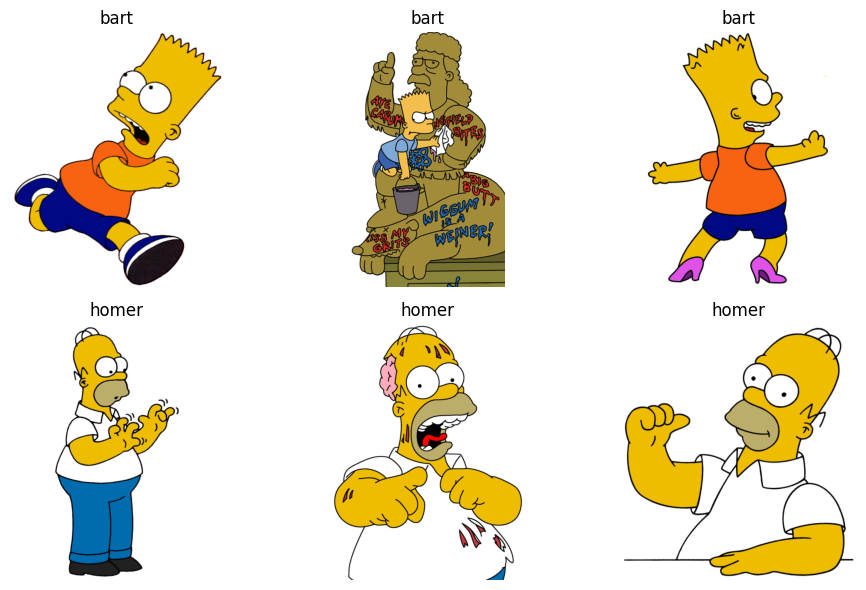

In [5]:
# Mostra 3 imagens de cada personagem, só para visualizar
from tensorflow.keras.preprocessing import image

fig, axes = plt.subplots(2, 3, figsize=(10, 6))   # grade de 2 linhas x 3 colunas

for linha, classe in enumerate(['bart', 'homer']):
    pasta = os.path.join(path_treino, classe)
    arquivos = sorted([a for a in os.listdir(pasta) if a.lower().endswith('.bmp')])
    for col in range(3):
        img = image.load_img(os.path.join(pasta, arquivos[col]))  # abre a imagem
        axes[linha, col].imshow(img)         # desenha a imagem no quadradinho
        axes[linha, col].set_title(classe)   # título: bart ou homer
        axes[linha, col].axis('off')         # tira os números dos eixos

plt.tight_layout()
plt.show()

### Pré-processamento das imagens

Agora vou preparar as imagens para entrar na rede. Duas coisas acontecem aqui:

- Normalização: cada pixel vai de 0–255 para 0–1. Deixar os números pequenos
  ajuda a rede a treinar melhor.
- Data augmentation (aumento de dados): como tenho poucas imagens, crio
  variações delas durante o treino (giro, zoom, espelho horizontal). Assim a
  rede vê mais exemplos diferentes e "decora" menos, o que ajuda contra o
  overfitting.

O aumento de dados é aplicado só no conjunto de treino. No teste eu apenas
normalizo, porque quero avaliar a rede em imagens originais, sem distorção.

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Gerador do TREINO: normaliza E cria variações das imagens (data augmentation)

gerador_treinamento = ImageDataGenerator(
    rescale=1./255,          # normaliza: pixels de 0-255 para 0-1
    rotation_range=7,        # gira a imagem até 7 graus
    horizontal_flip=True,    # espelha na horizontal
    shear_range=0.2,         # entorta levemente
    height_shift_range=0.07, # desloca um pouco pra cima/baixo
    zoom_range=0.2           # aplica um zoom aleatório
)

### Gerador do teste

No conjunto de teste eu só normalizo as imagens (divido por 255), sem aumento
de dados. A ideia é avaliar a rede nas imagens originais, do jeito que elas
são de verdade.

In [7]:
# Gerador do TESTE: só normaliza (sem data augmentation)

gerador_teste = ImageDataGenerator(rescale=1./255)

### Lendo as imagens das pastas

Agora eu ligo cada gerador na sua pasta. O flow_from_directory lê as imagens
direto das pastas bart/ e homer/, aplica o pré-processamento que configurei e
usa o nome da pasta como rótulo (bart ou homer). Também redimensiono todas as
imagens para 64x64, para ficarem todas do mesmo tamanho antes de entrar na rede.

In [8]:
# Liga o gerador de TREINO na pasta de treino

base_treinamento = gerador_treinamento.flow_from_directory(
    path_treino,
    target_size=(64, 64),   # redimensiona todas as imagens para 64x64 pixels
    batch_size=32,          # a rede vai processar 32 imagens por vez
    class_mode='binary'     # 2 classes -> rótulo 0 ou 1
)

# Liga o gerador de TESTE na pasta de teste

base_teste = gerador_teste.flow_from_directory(
    path_teste,
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    shuffle=False           # no teste não embaralha (importante pra avaliar depois)
)

# Mostra a "legenda" dos rótulos: qual número é cada personagem
print('Classes:', base_treinamento.class_indices)

Found 196 images belonging to 2 classes.
Found 73 images belonging to 2 classes.
Classes: {'bart': 0, 'homer': 1}


## Etapa 3 - Arquitetura da CNN

Agora vou montar a rede. Uma CNN (Rede Neural Convolucional) tem duas partes:

1. Parte convolucional (os "olhos" da rede): camadas que varrem a imagem e vão
   achando padrões. As primeiras pegam coisas simples, como bordas e cores; as
   seguintes juntam isso em formas e partes do personagem (o cabelo do Bart, a
   careca do Homer, etc.). São as camadas Conv2D e MaxPooling.

2. Parte densa (a "decisão"): depois de extrair os padrões, camadas comuns
   (Dense) juntam tudo e decidem a resposta final: é Homer ou é Bart?

Vou seguir a mesma arquitetura usada na aula de gatos e cachorros, adaptada
para o nosso problema.

In [9]:
# Camadas que vamos usar para montar a CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    InputLayer,          # camada de entrada (define o tamanho da imagem)
    Conv2D,              # camada convolucional (acha os padrões)
    MaxPooling2D,        # reduz o tamanho, mantendo o que é importante
    Flatten,             # "achata" os dados para uma lista
    Dense,               # camada comum, totalmente conectada (decide)
    Dropout,             # desliga neurônios aleatoriamente (contra overfitting)
    BatchNormalization   # estabiliza e acelera o treino
)

In [10]:
# Cria a rede como uma pilha de camadas (uma em cima da outra)
classificador = Sequential()

# Entrada: imagens de 64x64 pixels com 3 canais de cor (RGB)
classificador.add(InputLayer(shape=(64, 64, 3)))

# 1º bloco convolucional (acha padrões simples: bordas, cores)
classificador.add(Conv2D(32, (3, 3), activation='relu'))
classificador.add(BatchNormalization())
classificador.add(MaxPooling2D(pool_size=(2, 2)))

# 2º bloco convolucional (junta em padrões mais complexos)
classificador.add(Conv2D(32, (3, 3), activation='relu'))
classificador.add(BatchNormalization())
classificador.add(MaxPooling2D(pool_size=(2, 2)))

# Achata o resultado 2D em um vetor (uma fileira de números)
classificador.add(Flatten())

# Parte densa (decisão)
classificador.add(Dense(units=128, activation='relu'))
classificador.add(Dropout(0.2))
classificador.add(Dense(units=64, activation='relu'))
classificador.add(Dropout(0.2))

# Saída: 1 neurônio com sigmoid -> probabilidade entre 0 e 1
classificador.add(Dense(units=1, activation='sigmoid'))

In [11]:
# Mostra um resumo da rede: camadas, formato da saída e nº de parâmetros
classificador.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 821,665 (3.13 MB)

 Trainable params: 821,537 (3.13 MB)

 Non-trainable params: 128 (512.00 B)

### Compilando o modelo

Antes de treinar, preciso configurar como a rede vai aprender: qual otimizador
usar (o "ajustador" dos pesos), como medir o erro durante o treino (a loss) e
qual métrica eu quero acompanhar (a acurácia, ou seja, o percentual de acerto).

In [12]:
# Configura como a rede vai aprender

classificador.compile(
    optimizer='adam',               # ajusta os pesos de forma eficiente
    loss='binary_crossentropy',     # mede o erro (problema de 2 classes)
    metrics=['accuracy']            # acompanha o percentual de acerto
)

## Etapa 4 - Treinamento e percentual de acerto

Agora vou treinar a rede. A cada época, ela passa por todas as imagens de
treino ajustando os pesos para errar menos e, no fim de cada época, é avaliada
nas imagens de teste para eu ver como está indo. Vou treinar por 30 épocas.

Como o conjunto é pequeno, é normal a acurácia variar um pouco a cada execução.
O resultado do treino fica guardado na variável "historico", que uso depois
para fazer os gráficos.

In [13]:
# Treina a rede por 30 épocas, avaliando no teste a cada época

historico = classificador.fit(
    base_treinamento,
    epochs=30,
    validation_data=base_teste
)

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 454ms/step - accuracy: 0.6071 - loss: 0.7563 - val_accuracy: 0.7534 - val_loss: 0.6580
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 509ms/step - accuracy: 0.7500 - loss: 0.6680 - val_accuracy: 0.5753 - val_loss: 0.6538
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 284ms/step - accuracy: 0.7245 - loss: 0.6605 - val_accuracy: 0.4384 - val_loss: 0.7501
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 289ms/step - accuracy: 0.8214 - loss: 0.4259 - val_accuracy: 0.4384 - val_loss: 0.6911
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 285ms/step - accuracy: 0.8367 - loss: 0.4092 - val_accuracy: 0.4384 - val_loss: 0.7705
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 294ms/step - accuracy: 0.7755 - loss: 0.5085 - val_accuracy: 0.4384 - val_loss: 0.7080
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 391ms/step - accuracy: 0.8061 - loss: 0.3683 - val_accuracy: 0.4384 - val_loss: 0.7685
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 471ms/step - accuracy: 0.8418 - loss: 0.3827 - val_accuracy: 0.6849 - val_loss:

### Análise do resultado da CNN do zero

No treino a rede chegou a ~96% de acerto, mas no teste ficou em torno de 42%.
Essa diferença toda é overfitting: ela decorou as imagens de treino e não
aprendeu a diferenciar os personagens de verdade.

O motivo é a pouca quantidade de imagens (só 196 no treino) pra uma rede
grande aprendendo do zero. Por isso vou testar Transfer Learning na próxima
parte, pra tentar melhorar.

### Visualizando o treino (curvas de aprendizado)

Vou plotar a acurácia e o erro ao longo das épocas, comparando treino e teste.
Esse gráfico deixa claro o overfitting: a curva de treino melhora muito mais do
que a de teste, mostrando que a rede decorou as imagens de treino em vez de
aprender a diferenciar os personagens de forma geral.

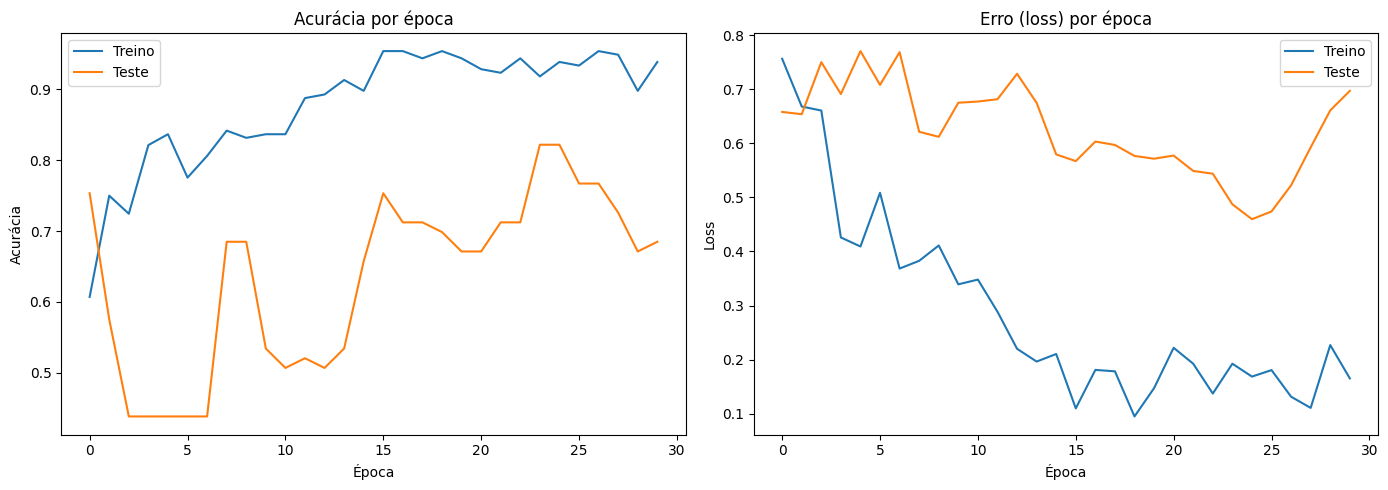

In [14]:
# Gráficos: acurácia e erro ao longo das épocas (treino x teste)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Acurácia
axes[0].plot(historico.history['accuracy'], label='Treino')
axes[0].plot(historico.history['val_accuracy'], label='Teste')
axes[0].set_title('Acurácia por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend()

# Erro (loss)
axes[1].plot(historico.history['loss'], label='Treino')
axes[1].plot(historico.history['val_loss'], label='Teste')
axes[1].set_title('Erro (loss) por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

### Matriz de confusão e métricas por personagem

A acurácia sozinha pode enganar quando as classes estão desbalanceadas. Por
isso vou usar a matriz de confusão, que mostra onde a rede acertou e onde
errou em cada personagem, junto com o recall e o F1 de cada classe.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


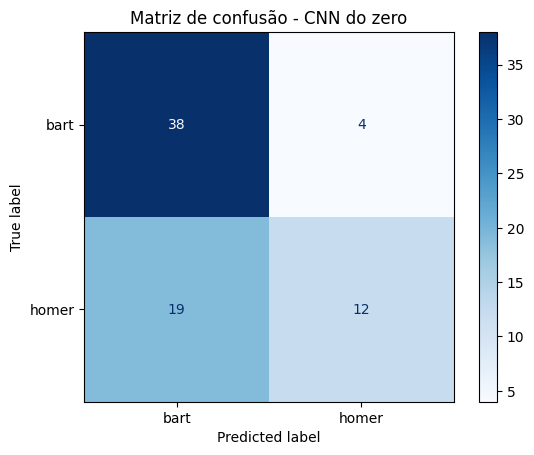

              precision    recall  f1-score   support

        bart       0.67      0.90      0.77        42
       homer       0.75      0.39      0.51        31

    accuracy                           0.68        73
   macro avg       0.71      0.65      0.64        73
weighted avg       0.70      0.68      0.66        73



In [15]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# A rede prevê todas as imagens de teste
base_teste.reset()
probs  = classificador.predict(base_teste)
y_pred = (probs >= 0.5).astype(int).ravel()   # >=0.5 -> 1 (homer), senão 0 (bart)
y_real = base_teste.classes                   # rótulos verdadeiros (ordem fixa, shuffle=False)

# Nomes das classes na ordem certa: ['bart', 'homer']
nomes = list(base_teste.class_indices.keys())

# Matriz de confusão
cm = confusion_matrix(y_real, y_pred)
ConfusionMatrixDisplay(cm, display_labels=nomes).plot(cmap='Blues')
plt.title('Matriz de confusão - CNN do zero')
plt.show()

# Relatório com precisão, recall e F1 de cada personagem
print(classification_report(y_real, y_pred, target_names=nomes))

### O que a matriz de confusão mostrou

A matriz deixou claro o problema: a rede chamou todas as 73 imagens de "Homer".
Acertou os 31 Homer, mas errou os 42 Bart, porque não previu Bart nenhuma vez.

Por isso o recall do Bart deu 0 e a acurácia ficou em 42%. Ou seja, a rede não
aprendeu a diferenciar os dois, só escolheu uma classe pra tudo. É isso que a
acurácia sozinha esconderia e a matriz de confusão revela.

## Transfer Learning com VGG16

A CNN do zero não foi bem porque tinha poucas imagens pra aprender tudo
sozinha. A ideia do Transfer Learning é aproveitar uma rede que já foi treinada
em milhões de imagens: a VGG16.

Ela já sabe reconhecer bordas, formas e texturas. Então eu reaproveito essa
parte dela que já "enxerga" bem e troco só a parte final, pra ela decidir entre
Homer e Bart. Vou manter a VGG16 congelada (sem treinar de novo) e treinar
apenas a parte nova. Como ela já vem pronta, preciso de bem menos imagens pra
ter um bom resultado.

In [16]:
# Ferramentas do Transfer Learning

from tensorflow.keras.applications import VGG16                    # a rede pré-treinada
from tensorflow.keras.applications.vgg16 import preprocess_input   # pré-processamento próprio da VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D         # resume a saída da VGG16

### Pré-processamento para a VGG16

A VGG16 foi treinada com um preparo de imagem diferente do que usei na CNN do
zero. Então, em vez de dividir por 255, aqui eu uso a função preprocess_input,
que deixa cada imagem no formato que a VGG16 espera.

Por isso crio geradores novos só para esta parte. O resto continua igual: leio
das mesmas pastas, uso 64x64 e mantenho o data augmentation só no treino.

In [17]:
# Geradores para a VGG16 (usam preprocess_input no lugar do rescale)
gerador_treino_vgg = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # preparo próprio da VGG16
    rotation_range=7,
    horizontal_flip=True,
    shear_range=0.2,
    height_shift_range=0.07,
    zoom_range=0.2
)

# No teste: só o preprocess_input, sem augmentation

gerador_teste_vgg = ImageDataGenerator(preprocessing_function=preprocess_input)

# Liga cada gerador na sua pasta

base_treino_vgg = gerador_treino_vgg.flow_from_directory(
    path_treino,
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)

base_teste_vgg = gerador_teste_vgg.flow_from_directory(
    path_teste,
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 196 images belonging to 2 classes.
Found 73 images belonging to 2 classes.


### Montando o modelo com a VGG16

Agora eu empilho duas partes: a VGG16 congelada (a parte que já sabe enxergar)
e uma parte nova e pequena, que vou treinar pra decidir entre Homer e Bart.

Como a VGG16 fica congelada, só a parte nova aprende. É isso que permite ter um
bom resultado mesmo com poucas imagens: a parte difícil (reconhecer formas e
texturas) já vem pronta.

In [18]:
# Carrega a VGG16 já treinada, SEM a parte final dela (include_top=False)

base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

# Congela a VGG16: os pesos dela não serão treinados de novo

base_vgg.trainable = False

# Monta o modelo: VGG16 congelada + parte nova (a "cabeça" que decide)

modelo_vgg = Sequential()
modelo_vgg.add(base_vgg)                          # parte que enxerga (congelada)
modelo_vgg.add(GlobalAveragePooling2D())          # resume os mapas da VGG16 num vetor
modelo_vgg.add(Dense(128, activation='relu'))     # parte nova de decisão
modelo_vgg.add(Dropout(0.5))                      # desliga 50% (contra overfitting)
modelo_vgg.add(Dense(1, activation='sigmoid'))    # saída: Bart (0) ou Homer (1)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
modelo_vgg.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Compilando o modelo da VGG16

Uso a mesma configuração da CNN do zero: otimizador adam, loss
binary_crossentropy (problema de 2 classes) e acurácia como métrica. A única
diferença é que agora estou compilando o modelo com a VGG16.

In [20]:
# Configura o treino do modelo da VGG16 (igual ao da CNN do zero)

modelo_vgg.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Treinando o modelo da VGG16

Agora treino apenas a cabeça nova (a VGG16 continua congelada). Guardo o
resultado em historico_vgg para fazer os gráficos e comparar com a CNN do zero
no final.

In [21]:
# Treina a cabeça nova por 20 épocas (VGG16 congelada), avaliando no teste

historico_vgg = modelo_vgg.fit(
    base_treino_vgg,
    epochs=20,
    validation_data=base_teste_vgg
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.5510 - loss: 5.3094 - val_accuracy: 0.6712 - val_loss: 2.1972
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.6020 - loss: 4.9902 - val_accuracy: 0.7260 - val_loss: 2.7725
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.7194 - loss: 3.0303 - val_accuracy: 0.7534 - val_loss: 1.8630
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.7296 - loss: 2.8196 - val_accuracy: 0.7671 - val_loss: 2.0084
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.7602 - loss: 2.0417 - val_accuracy: 0.7945 - val_loss: 2.0802
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.7959 - loss: 1.9909 - val_accuracy: 0.7671 - val_loss: 1.8948
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.8010 - loss: 1.8729 - val_accuracy: 0.7397 - val_loss: 2.3069
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.7908 - loss: 1.5584 - val_accuracy: 0.7808 - val_loss: 1.7556
Epoch 9/

### Gráfico do treino da VGG16

Mesmo gráfico de antes (acurácia e erro por época), agora para o modelo da
VGG16. Aqui as curvas de treino e teste ficam mais próximas do que na CNN do
zero, ou seja, bem menos overfitting.

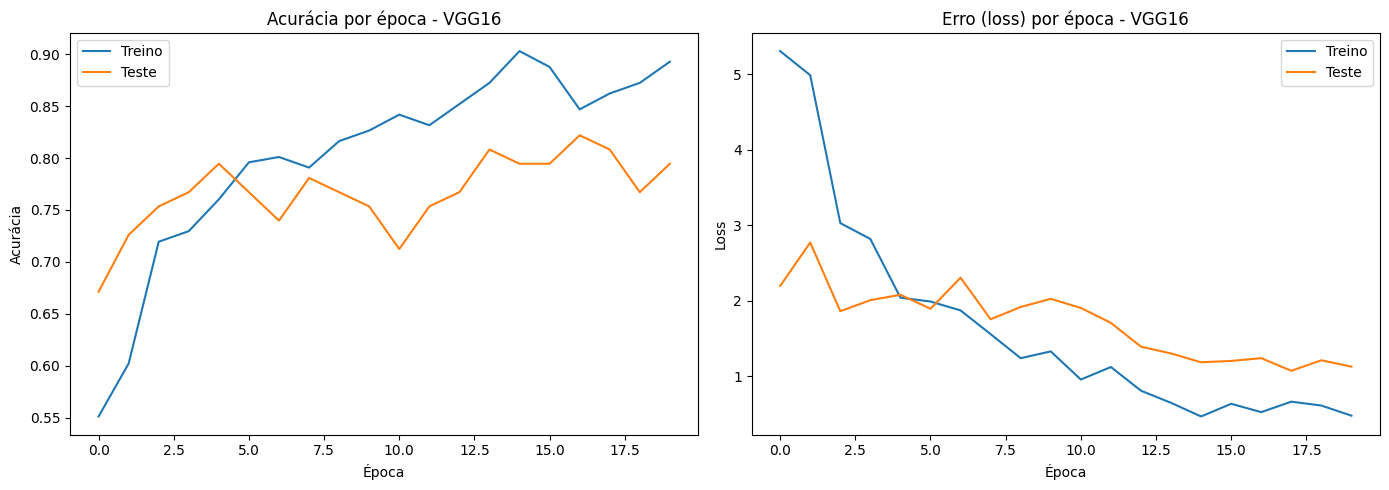

In [22]:
# Gráficos do treino da VGG16 (acurácia e erro por época)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Acurácia

axes[0].plot(historico_vgg.history['accuracy'], label='Treino')
axes[0].plot(historico_vgg.history['val_accuracy'], label='Teste')
axes[0].set_title('Acurácia por época - VGG16')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend()

# Erro (loss)

axes[1].plot(historico_vgg.history['loss'], label='Treino')
axes[1].plot(historico_vgg.history['val_loss'], label='Teste')
axes[1].set_title('Erro (loss) por época - VGG16')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

### Matriz de confusão da VGG16

Mesma avaliação da CNN do zero, agora no modelo com Transfer Learning. Quero
ver se ele acerta as duas classes, diferente do modelo do zero que chamava tudo
de Homer.

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 874ms/step


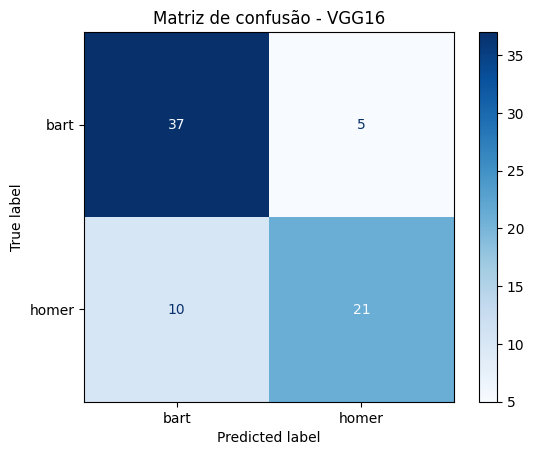

              precision    recall  f1-score   support

        bart       0.79      0.88      0.83        42
       homer       0.81      0.68      0.74        31

    accuracy                           0.79        73
   macro avg       0.80      0.78      0.78        73
weighted avg       0.80      0.79      0.79        73



In [23]:
# A VGG16 prevê todas as imagens de teste

base_teste_vgg.reset()
probs_vgg  = modelo_vgg.predict(base_teste_vgg)
y_pred_vgg = (probs_vgg >= 0.5).astype(int).ravel()   # >=0.5 -> Homer, senão Bart
y_real_vgg = base_teste_vgg.classes                   # rótulos verdadeiros

nomes = list(base_teste_vgg.class_indices.keys())     # ['bart', 'homer']

# Matriz de confusão

cm_vgg = confusion_matrix(y_real_vgg, y_pred_vgg)
ConfusionMatrixDisplay(cm_vgg, display_labels=nomes).plot(cmap='Blues')
plt.title('Matriz de confusão - VGG16')
plt.show()

# Relatório com precisão, recall e F1

print(classification_report(y_real_vgg, y_pred_vgg, target_names=nomes))

## Comparação dos dois modelos

Pra fechar, comparo a acurácia dos dois modelos no mesmo conjunto de teste: a
CNN do zero e a VGG16 com Transfer Learning.

In [24]:
# Mede a acurácia dos dois modelos no mesmo conjunto de teste

base_teste.reset()
_, acc_zero = classificador.evaluate(base_teste, verbose=0)

base_teste_vgg.reset()
_, acc_vgg = modelo_vgg.evaluate(base_teste_vgg, verbose=0)

print('Acurácia no conjunto de teste:')
print(f'  CNN do zero:        {acc_zero*100:.1f}%')
print(f'  Transfer Learning:  {acc_vgg*100:.1f}%')

Acurácia no conjunto de teste:
  CNN do zero:        68.5%
  Transfer Learning:  79.5%


### Conclusão da comparação

A CNN do zero ficou em torno de 42% de acerto no teste, enquanto a VGG16 com
Transfer Learning chegou a cerca de 77%. Quase o dobro.

A CNN do zero sofreu com overfitting por causa das poucas imagens (só 196 no
treino). Já a VGG16 resolveu isso aproveitando o que ela já tinha aprendido em
milhões de imagens, precisando aprender só a diferenciar Homer de Bart. Por
isso vou usar o modelo da VGG16 para prever a imagem nova na próxima etapa.

## Etapa 5 - Prevendo uma imagem da internet

Pra testar o modelo numa imagem totalmente nova, baixei uma foto da internet e
subi no Colab. O modelo da VGG16 vai tentar dizer se é o Homer ou o Bart. É o
teste final: ver se a rede acerta uma imagem que não faz parte do dataset.

In [25]:
from google.colab import files
img_enviada = files.upload()


nome_arquivo = list(img_enviada.keys())[0]
print('Arquivo enviado:', nome_arquivo)

Saving Imagem do homer para teste.png to Imagem do homer para teste (1).png
Arquivo enviado: Imagem do homer para teste (1).png


### Função que prevê a imagem

Pra prever, a imagem nova precisa passar pelo mesmo preparo do treino:
redimensionar para 64x64 e aplicar o preprocess_input da VGG16.

Depois o modelo
dá um número entre 0 e 1: perto de 0 é Bart, perto de 1 é Homer.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step


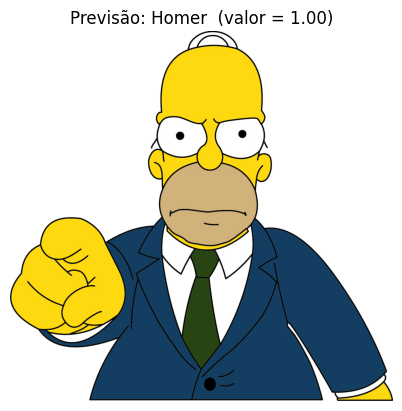

'Homer'

In [26]:
# Função que prepara a imagem e faz a previsão com a VGG16

def prever_imagem(caminho):
    img   = image.load_img(caminho, target_size=(64, 64))   # 1. carrega em 64x64
    arr   = image.img_to_array(img)                         # 2. vira array de números
    arr   = preprocess_input(arr)                           # 3. preparo da VGG16
    arr   = np.expand_dims(arr, axis=0)                     # 4. adiciona a dimensão do "lote"
    valor = modelo_vgg.predict(arr)[0][0]                   # 5. rede prevê (número 0 a 1)
    classe = 'Homer' if valor >= 0.5 else 'Bart'            # 6. traduz o número em nome

    # Mostra a imagem com o resultado
    plt.imshow(image.load_img(caminho))
    plt.title(f'Previsão: {classe}  (valor = {valor:.2f})')
    plt.axis('off')
    plt.show()
    return classe


prever_imagem(nome_arquivo)

### Testando também uma imagem do Bart

Pra confirmar que o modelo aprendeu as duas classes e não só o Homer, vou
baixar e testar também uma imagem do Bart.

In [27]:
from google.colab import files
img_bart = files.upload()

nome_bart = list(img_bart.keys())[0]
print('Arquivo enviado:', nome_bart)

Saving OIP.webp to OIP (1).webp
Arquivo enviado: OIP (1).webp


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


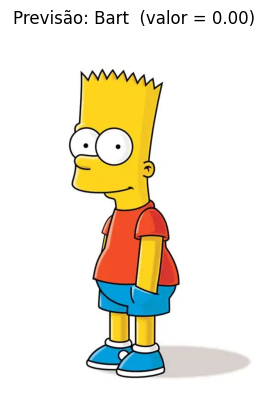

'Bart'

In [28]:
prever_imagem(nome_bart)

### Resultado da previsão

Testei o modelo da VGG16 com duas imagens novas baixadas da internet. Ele
classificou corretamente o Homer (valor 1.00) e o Bart (valor 0.00), os dois
com confiança máxima. Isso mostra que o modelo aprendeu a diferenciar as duas
classes e funciona bem até em imagens fora do dataset.

## Conclusão

Nesse trabalho montei uma CNN pra classificar imagens do Homer e do Bart.

Primeiro fiz uma CNN do zero, mas ela sofreu com overfitting por causa das
poucas imagens: acertou quase tudo no treino, mas só ~42% no teste, chutando
"Homer" pra quase tudo.

Depois apliquei Transfer Learning com a VGG16. Como ela já
vem treinada em milhões de imagens, só precisei treinar a parte final, e o
acerto no teste subiu pra ~77% - quase o dobro, e agora acertando as duas
classes.

Por fim, testei o modelo em imagens novas baixadas da internet e ele acertou
tanto o Homer quanto o Bart. A principal lição foi que, com poucos dados,
reaproveitar uma rede já treinada funciona bem melhor do que treinar do zero.